In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sbn
import sklearn as skl

In [2]:
dataFrameName = "diabetes_1.csv"
dataframe = pd.read_csv(dataFrameName) # , index_col = 'id')

In [3]:
dataframe.head(10)

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0
5,1008,248.0,94,69.0,3.6,4.81,Buckingham,34,male,71.0,190.0,large,132.0,86.0,NaN,NaN,36.0,42.0,195.0
6,1011,195.0,92,41.0,4.8,4.84,Buckingham,30,male,69.0,191.0,medium,161.0,112.0,161.0,112.0,46.0,49.0,720.0
7,1015,227.0,75,44.0,5.2,3.94,Buckingham,37,male,59.0,170.0,medium,NaN,NaN,NaN,NaN,34.0,39.0,1020.0
8,1016,177.0,87,49.0,3.6,4.84,Buckingham,45,male,69.0,166.0,large,160.0,80.0,128.0,86.0,34.0,40.0,300.0
9,1022,263.0,89,40.0,6.6,5.78,Buckingham,55,female,63.0,202.0,small,108.0,72.0,NaN,NaN,45.0,50.0,240.0


In [4]:
# some analysis: 
# print(dataframe.shape)
# 403 sample - 19 features
# print(dataframe.columns)
# 'chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'location', 'age',
# 'gender', 'height', 'weight', 'frame', 'bp.1s', 'bp.1d', 'bp.2s',
# 'bp.2d', 'waist', 'hip', 'time.ppn'

# waist is "girovita"

# dataframe.count(numeric_only = True)
# dataframe.describe()

# dataframe["gender"].value_counts().plot(kind='pie')
# dataframe["frame"].value_counts().plot(kind='pie')
# dataframe["age"].plot(kind='hist')
# print(dataframe.isnull().sum() )  # bp.2s e bp.2d should be deleted




# subjective selection of features based on my experience with diabetes:
df = dataframe[["glyhb", "stab.glu", "chol",  "hdl", 
                "ratio", "age", "frame", "height", 
                "weight",  "waist", "hip", "gender", 'bp.1s', 'bp.1d']].copy()
# we drop id, location + second check of pressure. Maybe later they could be interesting for further investigations
df.head()

,glyhb,stab.glu,chol,hdl,ratio,age,frame,height,weight,waist,hip,gender,bp.1s,bp.1d
0,4.31,82,203.0,56.0,3.6,46,medium,62.0,121.0,29.0,38.0,female,118.0,59.0
1,4.44,97,165.0,24.0,6.9,29,large,64.0,218.0,46.0,48.0,female,112.0,68.0
2,4.64,92,228.0,37.0,6.2,58,large,61.0,256.0,49.0,57.0,female,190.0,92.0
3,4.63,93,78.0,12.0,6.5,67,large,67.0,119.0,33.0,38.0,male,110.0,50.0
4,7.72,90,249.0,28.0,8.9,64,medium,68.0,183.0,44.0,41.0,male,138.0,80.0


In [5]:
# print(df.isnull().sum())

df.dropna(subset='glyhb', inplace = True) # these must be eliminated -> no way to be used
# df.dropna(subset='time.ppn', inplace=True)
df["frame"].replace(np.nan, "medium", inplace=True) # set to medium -> average 
df.dropna(subset='chol', inplace=True) # just one entrie so let's delete it. 
# indeed, cholesterole I guess it's a key parameter

# df[df["bp.1s"].isnull()] # just for checking 

# let's replace nan value with median: 
imputer = skl.impute.SimpleImputer(strategy='median')
df['height'] = imputer.fit_transform(df[['height']])
df['weight'] = imputer.fit_transform(df[['weight']])
df['waist'] = imputer.fit_transform(df[['waist']])
df['hip'] = imputer.fit_transform(df[['hip']])
df['bp.1s'] = imputer.fit_transform(df[['bp.1s']])
df['bp.1d'] = imputer.fit_transform(df[['bp.1d']])

df.isnull().sum()

glyhb       0
stab.glu    0
chol        0
hdl         0
ratio       0
age         0
frame       0
height      0
weight      0
waist       0
hip         0
gender      0
bp.1s       0
bp.1d       0
dtype: int64

In [6]:
# encoding

# semplice replace:
df["gender"].replace( {"male": 1, "female": 0} , inplace=True)

# df["gender"].value_counts().plot(kind='pie')

<Axes: ylabel='count'>

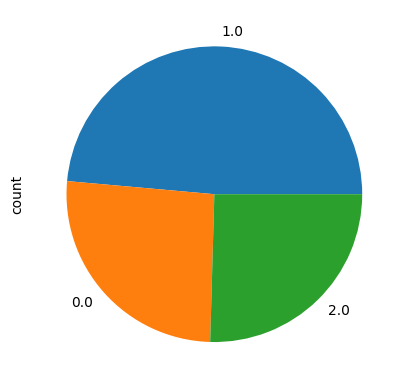

In [7]:
# encoding ordinale: 
df['frame'].unique()

ordEnc = skl.preprocessing.OrdinalEncoder( categories=[["small", "medium", "large"]])
df["frame"] = ordEnc.fit_transform(df[["frame"]])

df["frame"].value_counts().plot(kind='pie')

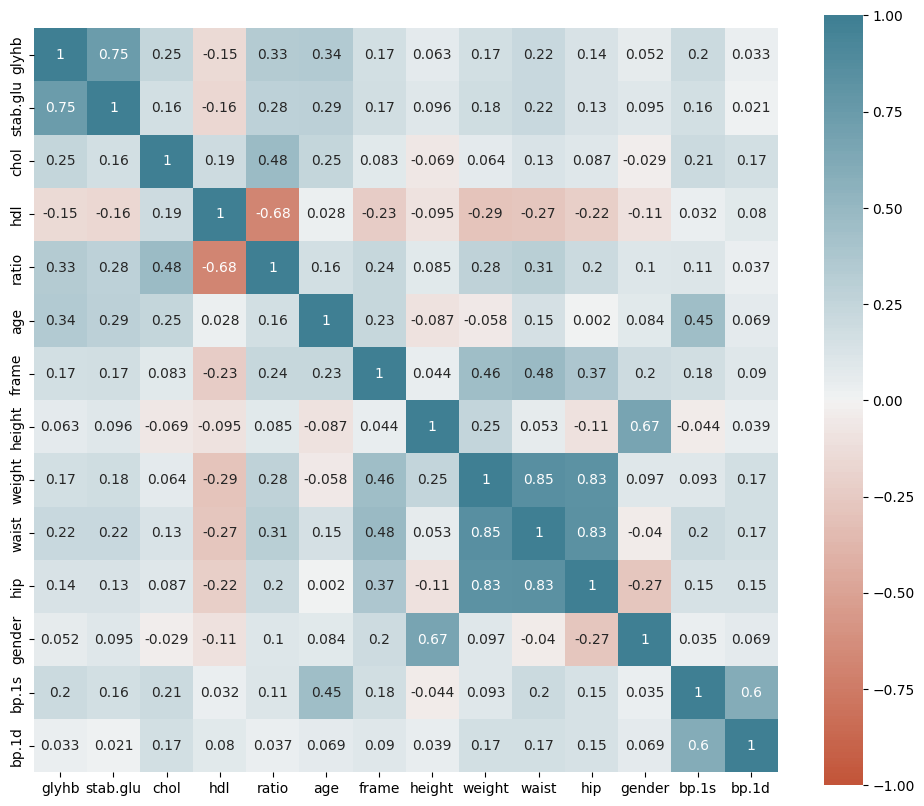

,feature_1,feature_2,correlation
134,waist,weight,0.847551
121,weight,waist,0.847551
149,hip,waist,0.833143
136,waist,hip,0.833143
148,hip,weight,0.826598


In [8]:
corrMatrix = df.corr()

plt.figure(figsize=(12,10))
sbn.heatmap(corrMatrix,  vmin=-1, vmax = 1, center = 0,
            cmap = sbn.diverging_palette(20,220, n=200),
            annot=True, square = True)
plt.show()

corr_df = corrMatrix.stack().reset_index()
corr_df.columns = ["feature_1", "feature_2", "correlation"]
corr_df.sort_values(by='correlation', ascending = False, inplace = True)
corr_df = corr_df[corr_df['feature_1'] != corr_df['feature_2'] ] # drop 1 values
corr_df.head()

In [9]:
# variance inflation Factor (VIF): multi-collinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor 

def calc_vif(X): # X: the data frame
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])] 
    vif.sort_values(by=['VIF'], ascending = True)
    return(vif)
    
calc_vif(df.drop(columns=['glyhb']))  # no target variable

,variables,VIF
0,stab.glu,6.008139
1,chol,86.687677
2,hdl,51.770173
3,ratio,53.526735
4,age,16.008696
5,frame,4.439944
6,height,154.912180
7,weight,118.416928
8,waist,237.723672
9,hip,313.299800


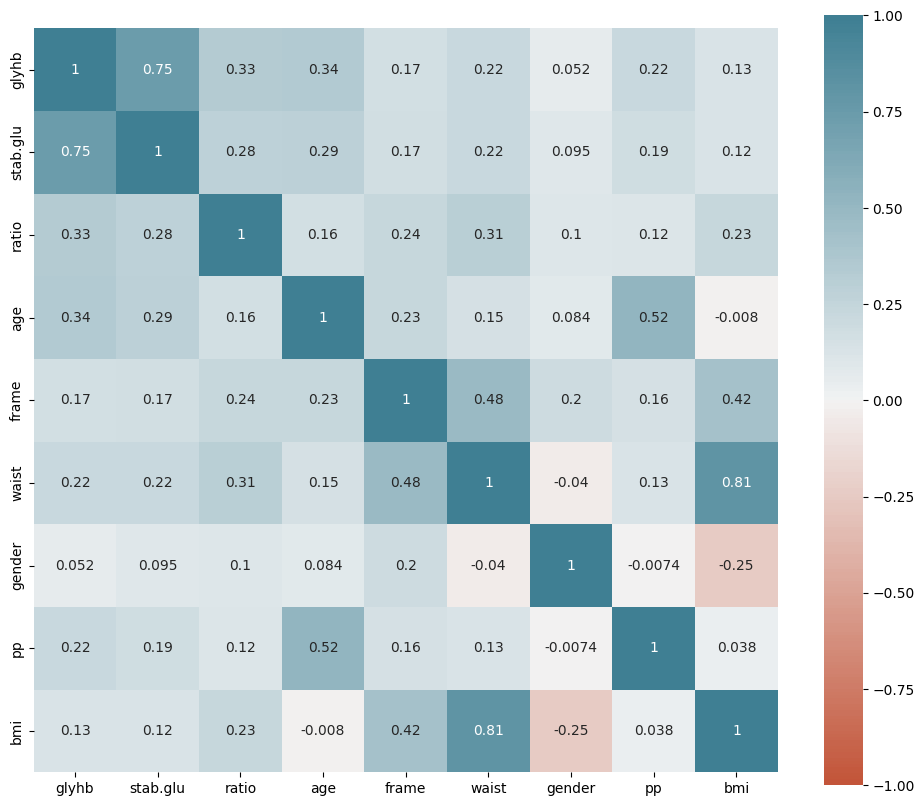

    feature_1 feature_2  correlation
134     waist    weight     0.847551
121    weight     waist     0.847551
149       hip     waist     0.833143
136     waist       hip     0.833143
148       hip    weight     0.826598


,variables,VIF
0,stab.glu,5.939638
1,ratio,9.244615
2,age,13.792889
3,frame,3.871337
4,waist,105.633880
5,gender,2.135722
6,pp,13.020779
7,bmi,73.954857


In [10]:
new_df = df.copy()
new_df["pp"] = new_df["bp.1s"]-new_df["bp.1d"]
new_df["bmi"] = new_df["weight"]/(new_df["height"]*new_df["height"])
new_df = new_df.drop(columns=['hip', 'height','weight', "bp.1d", "bp.1s", "chol", "hdl"])

new_corrMatrix = new_df.corr()

plt.figure(figsize=(12,10))
sbn.heatmap(new_corrMatrix,  vmin=-1, vmax = 1, center = 0,
            cmap = sbn.diverging_palette(20,220, n=200),
            annot=True, square = True)
plt.show()

new_corr_df = new_corrMatrix.stack().reset_index()
new_corr_df.columns = ["feature_1", "feature_2", "correlation"]
new_corr_df.sort_values(by='correlation', ascending = False, inplace = True)
new_corr_df = corr_df[corr_df['feature_1'] != corr_df['feature_2'] ] # drop 1 values
print(new_corr_df.head() )

calc_vif(new_df.drop(columns=['glyhb']))

In [11]:
new_df.drop(columns=["waist"], inplace=True)
# new_df.dtypes
new_df.head()

,glyhb,stab.glu,ratio,age,frame,gender,pp,bmi
0,4.31,82,3.6,46,1.0,0,59.0,0.031478
1,4.44,97,6.9,29,2.0,0,44.0,0.053223
2,4.64,92,6.2,58,2.0,0,98.0,0.068799
3,4.63,93,6.5,67,2.0,1,60.0,0.026509
4,7.72,90,8.9,64,1.0,1,58.0,0.039576


,young,middleAged,old,all,%-y,%-m,%-o
frame,,,,,,,
0.0,28,58,15,101,27.722772,57.425743,14.851485
1.0,28,115,46,189,14.814815,60.846561,24.338624
2.0,9,51,39,99,9.090909,51.515152,39.393939


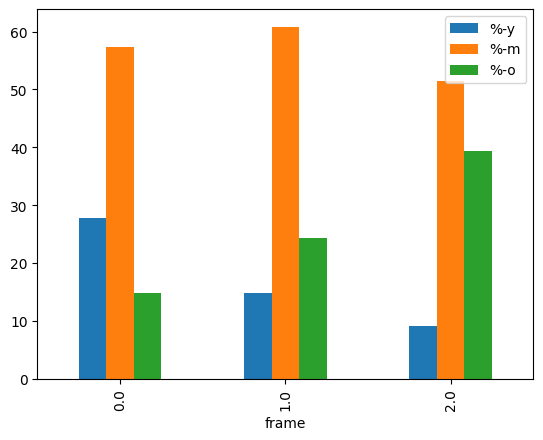

In [12]:
frame_df = pd.DataFrame([])
frame_df["all"] = new_df[['frame', 'gender']].groupby("frame").count()
frame_df["male"] = new_df[['frame', 'gender']].groupby("frame").sum()
frame_df["female"] = frame_df["all"]-frame_df["male"]
frame_df["male"] = frame_df["male"]/frame_df["all"]
frame_df["female"] = frame_df["female"]/frame_df["all"]
# frame_df[["male", "female"]].plot(kind='bar')


# exercise: old people | middle-aged | young VS frame
young_df = new_df[new_df["age"]<30]
middleAged_df = new_df[(new_df["age"] >= 30) & (new_df["age"] < 60)]
old_df = new_df[new_df["age"]>=60]

n_young = young_df.shape[0]
n_middleAged = middleAged_df.shape[0]
n_old = old_df.shape[0]
# young_df.groupby("frame").count() #bmi'].plot(kind='bar')

young_df = young_df.groupby("frame").count()["bmi"].to_frame()
young_df = young_df.rename(columns={'bmi': 'young'})
middleAged_df = middleAged_df.groupby("frame").count()["bmi"].to_frame()
middleAged_df = middleAged_df.rename(columns={'bmi': 'middleAged'})
old_df = old_df.groupby("frame").count()["bmi"].to_frame()
old_df = old_df.rename(columns={'bmi': 'old'})

age_df = pd.DataFrame([])
age_df["young"] = young_df["young"]
age_df["middleAged"] = middleAged_df["middleAged"]
age_df["old"] = old_df["old"]
age_df["all"] = frame_df["all"]

n_set = age_df.sum()["all"]

age_df["%-y"] = 100*age_df["young"]/age_df["all"]
age_df["%-m"] = 100*age_df["middleAged"]/age_df["all"]
age_df["%-o"] = 100*age_df["old"]/age_df["all"]



age_df[["%-y", "%-m", "%-o"]].plot(kind='bar')

age_df

In [13]:
# FEATURE RESCALING

new_df.head()

# new_df["glyhb"].hist(bins=25) # -> no gauss-dist - strong skewness
# new_df[["glyhb"]].boxplot()
# high values are important -> it indicates diabetes presence and severity
# glyhb must not be rescaled because it is the target feature

# new_df["stab.glu"].hist(bins=25) # robustscaler: strong skewness.
# new_df["ratio"].hist(bins=25) # robustscaler: strong skewness.
# new_df["age"].hist(bins=25) # robustscaler: strong skewness. 
# new_df["pp"].hist(bins=25) # robustscaler: weak skewness but still present
# new_df["bmi"].hist(bins=25) #  robustscaler: strong skewness. 
# new_df["frame"].hist(bins=25) # ordinal -> MinMaxScaler

,glyhb,stab.glu,ratio,age,frame,gender,pp,bmi
0,4.31,82,3.6,46,1.0,0,59.0,0.031478
1,4.44,97,6.9,29,2.0,0,44.0,0.053223
2,4.64,92,6.2,58,2.0,0,98.0,0.068799
3,4.63,93,6.5,67,2.0,1,60.0,0.026509
4,7.72,90,8.9,64,1.0,1,58.0,0.039576


In [14]:
rob_scaler = skl.preprocessing.RobustScaler()

new_df[['stab.glu','ratio', 'age', 'pp', 'bmi' ]] = rob_scaler.fit_transform(
                                    new_df[['stab.glu','ratio', 'age', 'pp', 'bmi' ]])

new_df

,glyhb,stab.glu,ratio,age,frame,gender,pp,bmi
0,4.310000,-0.296296,-0.272727,0.076923,1.0,0,0.40,-0.697738
1,4.440000,0.259259,1.227273,-0.576923,2.0,0,-0.35,1.187258
2,4.640000,0.074074,0.909091,0.538462,2.0,0,2.35,2.537488
3,4.630000,0.111111,1.045455,0.884615,2.0,1,0.45,-1.128428
4,7.720000,0.000000,2.136364,0.769231,1.0,1,0.35,0.004291
...,...,...,...,...,...,...,...,...
397,4.280000,0.000000,-0.727273,1.730769,1.0,0,3.85,-0.747319
398,16.110001,10.333333,1.000000,0.346154,1.0,1,-0.35,-0.276505
399,4.390000,-0.037037,0.500000,0.269231,1.0,0,-0.55,-0.062927
400,13.630000,6.629630,0.409091,-0.576923,0.0,0,-0.05,-0.385751


In [15]:
# new_df["bmi"].hist(bins=25)

mm_scaler = skl.preprocessing.MinMaxScaler()

new_df[['frame']] = mm_scaler.fit_transform(
                                    new_df[['frame']])

new_df


,glyhb,stab.glu,ratio,age,frame,gender,pp,bmi
0,4.310000,-0.296296,-0.272727,0.076923,0.5,0,0.40,-0.697738
1,4.440000,0.259259,1.227273,-0.576923,1.0,0,-0.35,1.187258
2,4.640000,0.074074,0.909091,0.538462,1.0,0,2.35,2.537488
3,4.630000,0.111111,1.045455,0.884615,1.0,1,0.45,-1.128428
4,7.720000,0.000000,2.136364,0.769231,0.5,1,0.35,0.004291
...,...,...,...,...,...,...,...,...
397,4.280000,0.000000,-0.727273,1.730769,0.5,0,3.85,-0.747319
398,16.110001,10.333333,1.000000,0.346154,0.5,1,-0.35,-0.276505
399,4.390000,-0.037037,0.500000,0.269231,0.5,0,-0.55,-0.062927
400,13.630000,6.629630,0.409091,-0.576923,0.0,0,-0.05,-0.385751


In [16]:
# ready to perform regression to extrapolate the target feature glyhb

X = new_df.drop(columns=['glyhb'])
Y = new_df['glyhb']

model = skl.linear_model.LinearRegression()
# now, let's perform the k-fold cross validation. let's k be equal to 10
# preliminary results:
lr_results = skl.model_selection.cross_validate(model, X, Y , cv=10)


In [17]:
print(lr_results)

meanscore = lr_results['test_score'].mean()

meanscore

# this must be improved. I guess the k-folding is not working for fold #5

{'fit_time': array([0.00264096, 0.00162292, 0.00122714, 0.00163531, 0.00146604,
       0.0012908 , 0.00126839, 0.00199938, 0.00157785, 0.00122595]), 'score_time': array([0.0011158 , 0.00085211, 0.00100541, 0.00092077, 0.00084233,
       0.00089002, 0.00091124, 0.00082397, 0.00107169, 0.00082207]), 'test_score': array([ 0.80279129,  0.60964509,  0.53238832,  0.54950754, -0.3946674 ,
        0.74989549,  0.44133037,  0.52633141,  0.24543379,  0.75860393])}


0.48212598288665093

In [18]:
X_train, X_test, Y_train, Y_test = skl.model_selection.train_test_split(X,Y , train_size = 0.7, random_state = 0)

In [19]:
model = skl.linear_model.LinearRegression() # re-initialised
model.fit(X_train, Y_train)
slope = model.coef_
print(slope)
intercept = model.intercept_
print(intercept)

[ 0.83730964  0.01182871  0.32034742 -0.2881748  -0.03868848  0.14594666
  0.03110778]
5.094326685649543


In [20]:
Y_pred = model.predict(X_test)
skl.metrics.r2_score(Y_test, Y_pred)

0.3649325742185956

In [21]:
# feature importance 


model = skl.linear_model.LinearRegression()
fitted_model = model.fit(X_train, Y_train)


permutation_score = skl.inspection.permutation_importance(fitted_model,
                                                          X_test, Y_test, scoring='r2', n_repeats=100)

importance_df = pd.DataFrame({'Feature': X.columns, 'Score_Decrease':permutation_score.importances_mean})
importance_df

,Feature,Score_Decrease
0,stab.glu,0.743184
1,ratio,0.002365
2,age,0.021836
3,frame,-0.010322
4,gender,0.000545
5,pp,0.001087
6,bmi,0.002691


In [22]:
X = X.drop(columns = ['ratio', 'gender', 'pp', 'bmi'])

model = skl.linear_model.LinearRegression()

scores = skl.model_selection.cross_val_score(model, X, Y, cv = 10)

simplified_model_score = scores.mean()

simplified_model_score

0.4761144124816319